In [1]:
import numpy as np
wavelength = 575e-9 # wavelength in meters
D = 6 # telescope diameter in meters
visual_range = 72 # in lambda/D

target_pixel = 448*2 # in pixels
r_earth = 1 # Earth to Sun distance in AU
rad_to_arcsecond = 206264.806247

psf_scale = wavelength/D*rad_to_arcsecond*visual_range/target_pixel # arcsec per pixel
print(psf_scale*1000) # in mas per pixel

visual_range = 56.875 # in lambda/D
psf_scale = wavelength/D*rad_to_arcsecond*visual_range/target_pixel # arcsec per pixel
print(psf_scale*1000) # in mas per pixel

1.5884231731074778
1.2547439995901082


(896, 896)
1.7707197383916018e-06


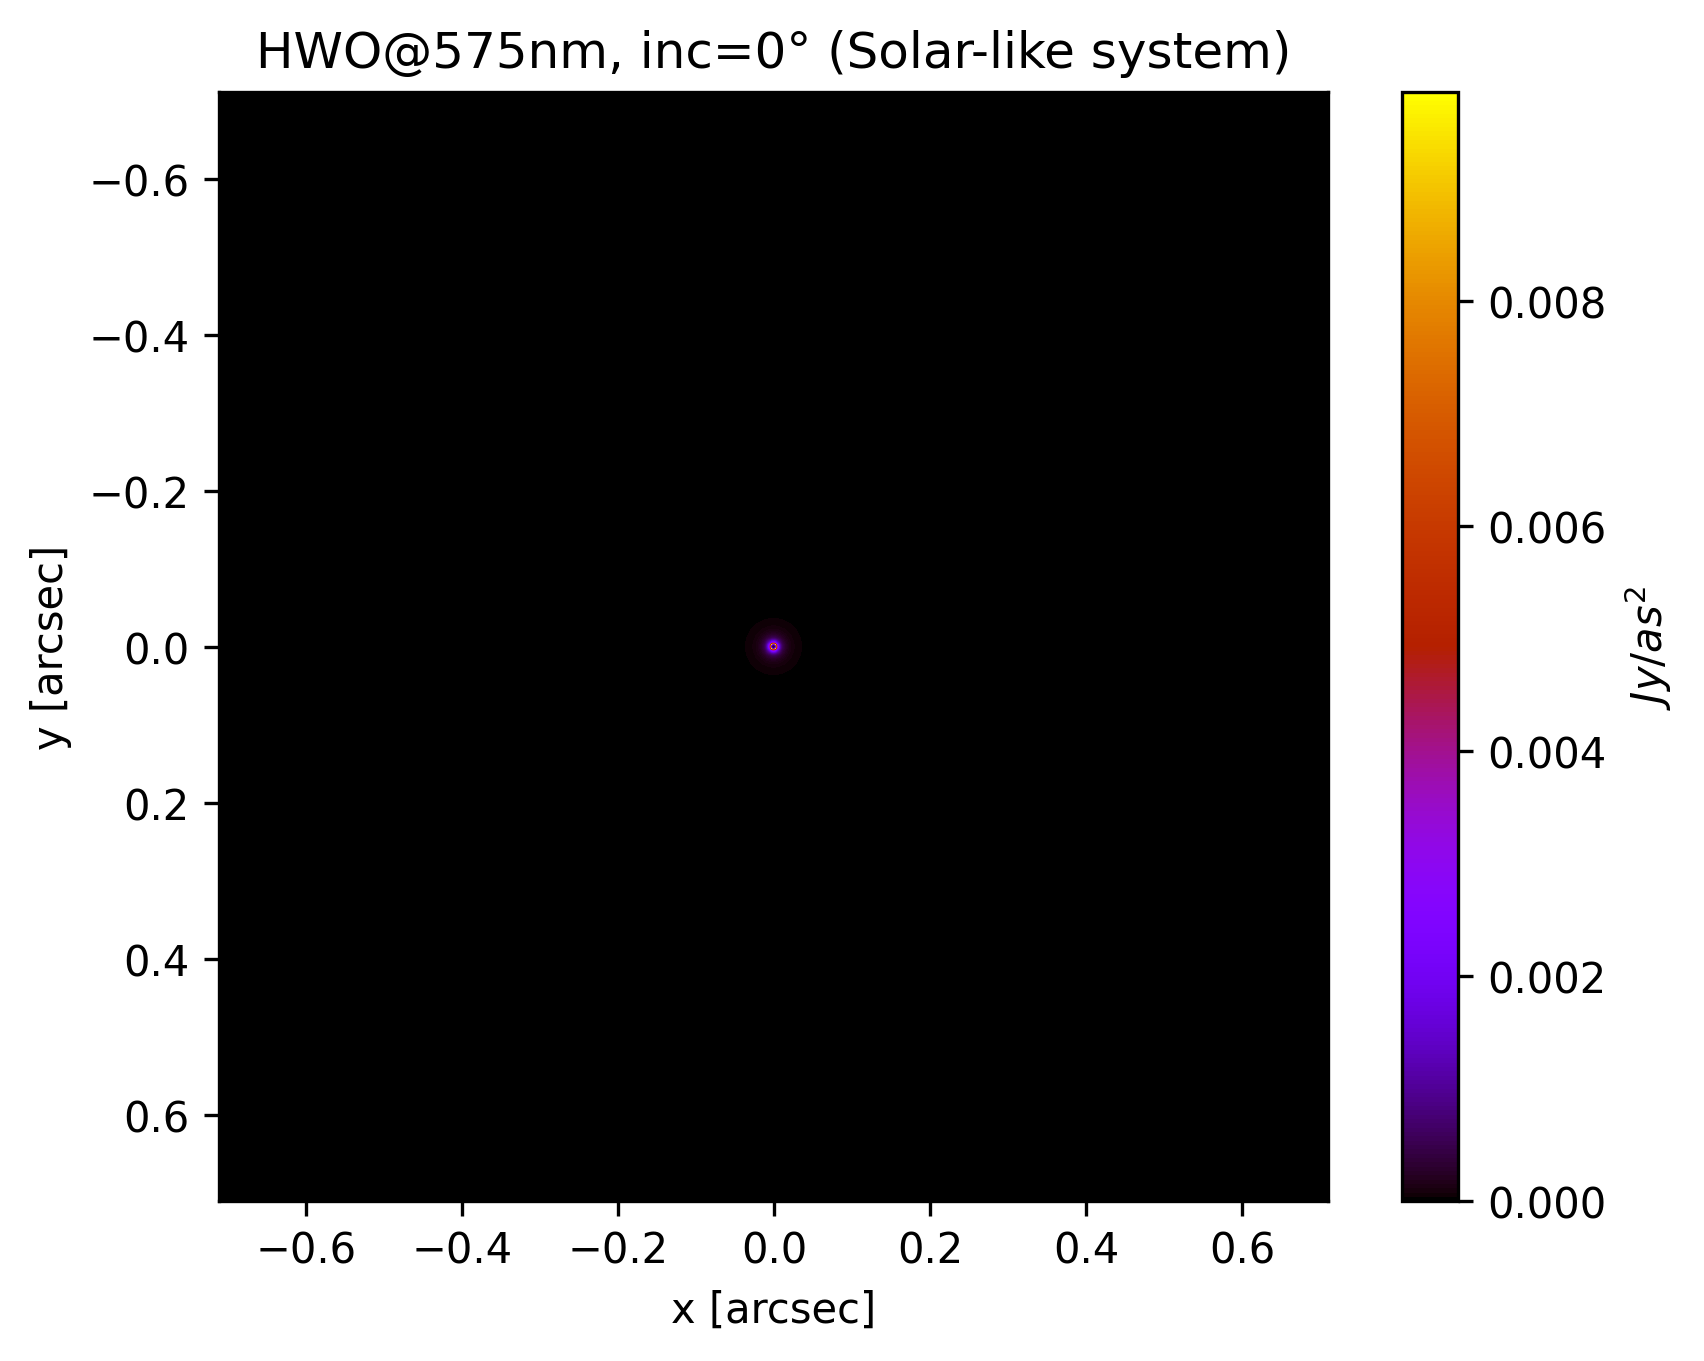

In [2]:
# Read the Solar System from ZODIPIC
import numpy as np
from scipy.io import readsav
import matplotlib.pyplot as plt

# Choose the visual range for the ZODIPIC PSF
#1.2547439995901082 mas per pixel for 56.875 lambda/D at 575 nm with a 6 m telescope
#1.5884231731074778 mas per pixel for 72 lambda/D at 575 nm with a 6 m telescope
folder_dir = "1zodi_72" # folder_dir = "1zodi_56875"
zodipic_psf_scale = 1.5884231731074778/1000 # arcsec per pixel
#########################

# Other parameters for ZODIPIC
zodipic_inc = 0 # inclination of the system in degrees, 0 means face-on, 90 means edge-on
zodipic_wavelength_nm = 575 # wavelength in nm

# Read the ZODIPIC data
sav_data = readsav(folder_dir+f"/1zodi{zodipic_inc}.sav") # the inner radius truncation is determined by the sublimation, 0.0287629 au
print(np.shape(sav_data['inu']))

zodipic_pixel_num = np.shape(sav_data['inu'])[0] # 896, number of pixels in one dimension

fig=plt.figure(dpi=300)
ax2=plt.subplot(111)
xpix=(np.arange (-zodipic_pixel_num/2, zodipic_pixel_num/2, 1))*zodipic_psf_scale
ypix=(np.arange (-zodipic_pixel_num/2, zodipic_pixel_num/2, 1))*zodipic_psf_scale
im2=ax2.imshow(sav_data['inu']/zodipic_psf_scale**2,
               cmap='gnuplot',extent=[np.min(ypix),np.max(ypix),np.min(xpix),np.max(xpix)])
ax2.invert_yaxis()
ax2.set_ylabel('y [arcsec]')
ax2.set_xlabel('x [arcsec]')
plt.title("{}@{}nm, inc={}\N{degree sign} (Solar-like system)".format("HWO", zodipic_wavelength_nm, zodipic_inc))
cb=plt.colorbar(im2,orientation='vertical')
cb.set_label("$Jy/as^2$")
#fig.savefig(file_dir+'Su_model_575nm_inc0_pa266.pdf', format='pdf', bbox_inches='tight')
print(np.sum(sav_data['inu'])) # total flux in Jy